# 01 — Full M5 Data Audit

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook checks all five downloaded M5 files before cleaning or modeling. It reads large tables in chunks so the audit can run in Google Colab without loading the complete transformed dataset into memory.

The notebook does not overwrite anything in `data/raw`. Findings are saved to `reports/`.

## 1. Setup and data location

The same code works when the notebook is started from the repository root or from the `notebooks` folder. In Colab, clone the repository and place the five M5 CSV files in `data/raw` before running the audit.

In [1]:
from pathlib import Path
import gc
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data/raw. Run from the repository or add M5 files in Colab.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", DATA_DIR)

Project root: F:\7) AI-ML_Fundamental_Project\Git_Desktop\retail-demand-forecasting
Raw data: F:\7) AI-ML_Fundamental_Project\Git_Desktop\retail-demand-forecasting\data\raw


## 2. File inventory

First, verify that every required file exists. SHA-256 hashes make it possible to prove later that the raw files were not changed.

In [2]:
REQUIRED_FILES = [
    "calendar.csv",
    "sales_train_evaluation.csv",
    "sales_train_validation.csv",
    "sample_submission.csv",
    "sell_prices.csv",
]

missing_files = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
assert not missing_files, f"Missing required files: {missing_files}"

def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        while block := file.read(block_size):
            digest.update(block)
    return digest.hexdigest()

inventory = pd.DataFrame([
    {
        "file": name,
        "size_mb": (DATA_DIR / name).stat().st_size / 1024**2,
        "sha256": sha256_file(DATA_DIR / name),
    }
    for name in REQUIRED_FILES
])
display(inventory)

,file,size_mb,sha256
0,calendar.csv,0.099,d12b5914ef03e66649adf5dd9e996e6602251c22b7a6af...
1,sales_train_evaluation.csv,116.097,4b4a47c44c38380d2a9168216fea8c9ff2f31b1ddb772f...
2,sales_train_validation.csv,114.448,f368e66ed1dbecb48b2cc8fc589bf68b3deddbbb36bf5c...
3,sample_submission.csv,4.987,eb7597afbec367475ef25dc6dbbc009b8faa47fa210725...
4,sell_prices.csv,193.973,9da3ad1f8b8ccacdbdc70612191dd375ec24a4ac6625c2...


## 3. Calendar audit

Calendar event columns are optional: most ordinary days have no named event, so their empty cells are expected. Required date, week, and SNAP fields are checked separately.

In [3]:
calendar = pd.read_csv(DATA_DIR / "calendar.csv")
calendar["parsed_date"] = pd.to_datetime(calendar["date"], errors="coerce")

calendar_required = [
    "date", "wm_yr_wk", "weekday", "wday", "month", "year", "d",
    "snap_CA", "snap_TX", "snap_WI",
]
calendar_optional = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]

calendar_result = {
    "rows": len(calendar),
    "columns": len(calendar.columns) - 1,
    "date_min": str(calendar["parsed_date"].min().date()),
    "date_max": str(calendar["parsed_date"].max().date()),
    "invalid_dates": int(calendar["parsed_date"].isna().sum()),
    "missing_required": int(calendar[calendar_required].isna().sum().sum()),
    "duplicate_dates": int(calendar.duplicated("date").sum()),
    "duplicate_day_ids": int(calendar.duplicated("d").sum()),
    "consecutive_dates": bool(calendar["parsed_date"].sort_values().diff().dropna().eq(pd.Timedelta(days=1)).all()),
}

optional_missing = calendar[calendar_optional].isna().sum().rename("missing_rows")
display(pd.Series(calendar_result, name="value").to_frame())
display(optional_missing.to_frame())

,value
rows,1969
columns,14
date_min,2011-01-29
date_max,2016-06-19
invalid_dates,0
missing_required,0
duplicate_dates,0
duplicate_day_ids,0
consecutive_dates,True


,missing_rows
event_name_1,1807
event_type_1,1807
event_name_2,1964
event_type_2,1964


## 4. Full sales-table audit

Both wide sales files are scanned in chunks. Every daily value is checked for missing, non-numeric, fractional, and negative values. Zero sales are counted but are not treated as errors because intermittent demand is normal in retail.

Very high sales are flagged using the 99.9th percentile. A flagged value is a review candidate, not automatically an error.

In [4]:
SALES_ID_COLUMNS = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

def histogram_quantile(histogram, quantile):
    target = quantile * histogram.sum()
    return int(np.searchsorted(np.cumsum(histogram), target, side="left"))

def audit_sales_file(path, chunk_size=250):
    header = pd.read_csv(path, nrows=0).columns.tolist()
    day_columns = [column for column in header if column.startswith("d_")]
    day_numbers = [int(column.split("_")[1]) for column in day_columns]
    expected_days = list(range(day_numbers[0], day_numbers[-1] + 1))

    result = {
        "file": path.name,
        "rows": 0,
        "columns": len(header),
        "day_columns": len(day_columns),
        "first_day": day_columns[0],
        "last_day": day_columns[-1],
        "consecutive_day_columns": day_numbers == expected_days,
        "missing_identifiers": 0,
        "missing_sales": 0,
        "non_numeric_sales": 0,
        "negative_sales": 0,
        "fractional_sales": 0,
        "zero_sales": 0,
        "total_sales_cells": 0,
        "minimum_sales": np.inf,
        "maximum_sales": -np.inf,
    }
    series_key_hashes = []
    histogram = np.zeros(1, dtype=np.int64)
    unique_values = {column: set() for column in SALES_ID_COLUMNS}
    item_hierarchy = set()
    store_states = set()

    for chunk in pd.read_csv(path, chunksize=chunk_size):
        result["rows"] += len(chunk)
        result["missing_identifiers"] += int(chunk[SALES_ID_COLUMNS].isna().sum().sum())
        series_key_hashes.append(pd.util.hash_pandas_object(chunk[["store_id", "item_id"]], index=False).to_numpy(np.uint64))
        for column in unique_values:
            unique_values[column].update(chunk[column].dropna().astype(str).unique())
        item_hierarchy.update(map(tuple, chunk[["item_id", "dept_id", "cat_id"]].drop_duplicates().to_numpy()))
        store_states.update(map(tuple, chunk[["store_id", "state_id"]].drop_duplicates().to_numpy()))

        raw_sales = chunk[day_columns]
        numeric_sales = raw_sales.apply(pd.to_numeric, errors="coerce")
        non_numeric = numeric_sales.isna() & raw_sales.notna()
        values = numeric_sales.to_numpy(dtype=np.float32, na_value=np.nan)
        finite = np.isfinite(values)

        result["missing_sales"] += int(raw_sales.isna().sum().sum())
        result["non_numeric_sales"] += int(non_numeric.sum().sum())
        result["negative_sales"] += int(np.count_nonzero(values[finite] < 0))
        result["fractional_sales"] += int(np.count_nonzero(np.mod(values[finite], 1) != 0))
        result["zero_sales"] += int(np.count_nonzero(values[finite] == 0))
        result["total_sales_cells"] += int(values.size)

        if finite.any():
            finite_values = values[finite]
            result["minimum_sales"] = min(result["minimum_sales"], float(finite_values.min()))
            result["maximum_sales"] = max(result["maximum_sales"], float(finite_values.max()))
            valid_integers = finite_values[(finite_values >= 0) & (np.mod(finite_values, 1) == 0)].astype(np.int64)
            chunk_histogram = np.bincount(valid_integers)
            if len(chunk_histogram) > len(histogram):
                histogram = np.pad(histogram, (0, len(chunk_histogram) - len(histogram)))
            histogram[:len(chunk_histogram)] += chunk_histogram

        del raw_sales, numeric_sales, values
        gc.collect()

    combined_hashes = np.concatenate(series_key_hashes)
    result["duplicate_series_keys"] = int(len(combined_hashes) - len(np.unique(combined_hashes)))
    item_hierarchy_frame = pd.DataFrame(item_hierarchy, columns=["item_id", "dept_id", "cat_id"])
    store_state_frame = pd.DataFrame(store_states, columns=["store_id", "state_id"])
    result["item_hierarchy_conflicts"] = int((item_hierarchy_frame.groupby("item_id").size() > 1).sum())
    result["store_state_conflicts"] = int((store_state_frame.groupby("store_id").size() > 1).sum())
    result["zero_sales_pct"] = 100 * result["zero_sales"] / result["total_sales_cells"]
    result["sales_p99_9"] = histogram_quantile(histogram, 0.999)
    result["values_above_p99_9"] = int(histogram[result["sales_p99_9"] + 1:].sum())
    result["unique_counts"] = {column: len(values) for column, values in unique_values.items()}

    return result, histogram, unique_values, day_columns

evaluation_result, evaluation_histogram, evaluation_sets, evaluation_days = audit_sales_file(
    DATA_DIR / "sales_train_evaluation.csv"
)
validation_result, validation_histogram, validation_sets, validation_days = audit_sales_file(
    DATA_DIR / "sales_train_validation.csv"
)

display(pd.DataFrame([evaluation_result, validation_result]).drop(columns="unique_counts"))
display(pd.DataFrame([evaluation_result["unique_counts"], validation_result["unique_counts"]], index=["evaluation", "validation"]))

,file,rows,columns,day_columns,first_day,last_day,consecutive_day_columns,missing_identifiers,missing_sales,non_numeric_sales,negative_sales,fractional_sales,zero_sales,total_sales_cells,minimum_sales,maximum_sales,duplicate_series_keys,item_hierarchy_conflicts,store_state_conflicts,zero_sales_pct,sales_p99_9,values_above_p99_9
0,sales_train_evaluation.csv,30490,1947,1941,d_1,d_1941,True,0,0,0,0,0,40241819,59181090,0.000,763.000,0,0,0,67.998,47,57465
1,sales_train_validation.csv,30490,1919,1913,d_1,d_1913,True,0,0,0,0,0,39777094,58327370,0.000,763.000,0,0,0,68.196,47,56800


,id,item_id,dept_id,cat_id,store_id,state_id
evaluation,30490,3049,7,3,10,3
validation,30490,3049,7,3,10,3


## 5. Full price-table audit

All price rows are checked in chunks. The business key is `(store_id, item_id, wm_yr_wk)`. Missing, invalid, non-positive, and duplicate key values would require cleaning. Prices above the 99.9th percentile are only flagged for review.

In [5]:
def audit_prices(path, chunk_size=250_000):
    result = {
        "rows": 0,
        "missing_keys": 0,
        "invalid_weeks": 0,
        "missing_prices": 0,
        "non_numeric_prices": 0,
        "non_positive_prices": 0,
    }
    key_columns = ["store_id", "item_id", "wm_yr_wk"]
    key_hashes = []
    all_prices = []
    stores, items, weeks = set(), set(), set()

    for chunk in pd.read_csv(path, dtype=str, chunksize=chunk_size):
        result["rows"] += len(chunk)
        result["missing_keys"] += int(chunk[key_columns].isna().sum().sum())
        key_hashes.append(pd.util.hash_pandas_object(chunk[key_columns], index=False).to_numpy(np.uint64))

        numeric_weeks = pd.to_numeric(chunk["wm_yr_wk"], errors="coerce")
        numeric_prices = pd.to_numeric(chunk["sell_price"], errors="coerce")
        result["invalid_weeks"] += int(numeric_weeks.isna().sum() - chunk["wm_yr_wk"].isna().sum())
        result["missing_prices"] += int(chunk["sell_price"].isna().sum())
        result["non_numeric_prices"] += int((numeric_prices.isna() & chunk["sell_price"].notna()).sum())
        result["non_positive_prices"] += int((numeric_prices <= 0).sum())

        valid_prices = numeric_prices.dropna().to_numpy(dtype=np.float32)
        all_prices.append(valid_prices)
        stores.update(chunk["store_id"].dropna().unique())
        items.update(chunk["item_id"].dropna().unique())
        weeks.update(numeric_weeks.dropna().astype(np.int64).unique().tolist())

    combined_hashes = np.concatenate(key_hashes)
    price_values = np.concatenate(all_prices)
    result["duplicate_business_keys"] = int(len(combined_hashes) - len(np.unique(combined_hashes)))
    result["minimum_price"] = float(price_values.min())
    result["maximum_price"] = float(price_values.max())
    result["price_p99_9"] = float(np.quantile(price_values, 0.999))
    result["values_above_p99_9"] = int(np.count_nonzero(price_values > result["price_p99_9"]))
    result["unique_stores"] = len(stores)
    result["unique_items"] = len(items)
    result["unique_weeks"] = len(weeks)
    return result, price_values, {"store_id": stores, "item_id": items, "wm_yr_wk": weeks}

price_result, price_values, price_sets = audit_prices(DATA_DIR / "sell_prices.csv")
display(pd.Series(price_result, name="value").to_frame())

,value
rows,"6,841,121.000"
missing_keys,0.000
invalid_weeks,0.000
missing_prices,0.000
non_numeric_prices,0.000
non_positive_prices,0.000
duplicate_business_keys,0.000
minimum_price,0.010
maximum_price,107.320
price_p99_9,28.960


## 6. Submission-format audit

The sample file should contain one unique ID and 28 forecast columns (`F1`–`F28`). Each base series should have both validation and evaluation rows.

In [6]:
submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
forecast_columns = [column for column in submission.columns if column.startswith("F")]
forecast_numeric = submission[forecast_columns].apply(pd.to_numeric, errors="coerce")
base_ids = submission["id"].str.replace(r"_(validation|evaluation)$", "", regex=True)
suffixes = submission["id"].str.extract(r"_(validation|evaluation)$", expand=False)
pair_table = pd.crosstab(base_ids, suffixes)

submission_result = {
    "rows": len(submission),
    "forecast_columns": len(forecast_columns),
    "forecast_columns_are_F1_to_F28": forecast_columns == [f"F{number}" for number in range(1, 29)],
    "missing_ids": int(submission["id"].isna().sum()),
    "duplicate_ids": int(submission.duplicated("id").sum()),
    "missing_forecasts": int(submission[forecast_columns].isna().sum().sum()),
    "non_numeric_forecasts": int((forecast_numeric.isna() & submission[forecast_columns].notna()).sum().sum()),
    "negative_forecasts": int((forecast_numeric < 0).sum().sum()),
    "unpaired_base_series": int((pair_table.reindex(columns=["validation", "evaluation"], fill_value=0) != 1).any(axis=1).sum()),
}
display(pd.Series(submission_result, name="value").to_frame())

,value
rows,60980
forecast_columns,28
forecast_columns_are_F1_to_F28,True
missing_ids,0
duplicate_ids,0
missing_forecasts,0
non_numeric_forecasts,0
negative_forecasts,0
unpaired_base_series,0


## 7. Cross-file consistency

A file can look valid on its own but still fail to match another table. These checks compare day IDs, week IDs, products, stores, and the shared history in the validation and evaluation sales files.

In [7]:
calendar_days = set(calendar["d"].dropna().astype(str))
calendar_weeks = set(calendar["wm_yr_wk"].dropna().astype(int))

def compare_validation_prefix(validation_path, evaluation_path, validation_days, chunk_size=200):
    use_columns = SALES_ID_COLUMNS + validation_days
    validation_reader = pd.read_csv(validation_path, usecols=use_columns, chunksize=chunk_size)
    evaluation_reader = pd.read_csv(evaluation_path, usecols=use_columns, chunksize=chunk_size)
    id_mismatches = 0
    sales_mismatches = 0
    compared_rows = 0

    for validation_chunk, evaluation_chunk in zip(validation_reader, evaluation_reader):
        validation_ids = validation_chunk["id"].str.replace("_validation", "_evaluation", regex=False)
        id_mismatches += int((validation_ids.to_numpy() != evaluation_chunk["id"].to_numpy()).sum())
        validation_values = validation_chunk[validation_days].to_numpy()
        evaluation_values = evaluation_chunk[validation_days].to_numpy()
        sales_mismatches += int(np.count_nonzero(validation_values != evaluation_values))
        compared_rows += len(validation_chunk)

    return {
        "compared_rows": compared_rows,
        "id_mismatches": id_mismatches,
        "sales_value_mismatches": sales_mismatches,
    }

prefix_result = compare_validation_prefix(
    DATA_DIR / "sales_train_validation.csv",
    DATA_DIR / "sales_train_evaluation.csv",
    validation_days,
)

cross_file_result = {
    "evaluation_days_missing_from_calendar": len(set(evaluation_days) - calendar_days),
    "validation_days_missing_from_calendar": len(set(validation_days) - calendar_days),
    "price_weeks_missing_from_calendar": len(price_sets["wm_yr_wk"] - calendar_weeks),
    "price_stores_missing_from_sales": len(price_sets["store_id"] - evaluation_sets["store_id"]),
    "price_items_missing_from_sales": len(price_sets["item_id"] - evaluation_sets["item_id"]),
    "submission_series_missing_from_sales": len(set(base_ids) - {value.replace("_evaluation", "") for value in evaluation_sets["id"]}),
    "sales_series_missing_from_submission": len({value.replace("_evaluation", "") for value in evaluation_sets["id"]} - set(base_ids)),
    "validation_sales_value_mismatches": prefix_result["sales_value_mismatches"],
    "validation_id_mismatches": prefix_result["id_mismatches"],
}
display(pd.Series(cross_file_result, name="value").to_frame())

,value
evaluation_days_missing_from_calendar,0
validation_days_missing_from_calendar,0
price_weeks_missing_from_calendar,0
price_stores_missing_from_sales,0
price_items_missing_from_sales,0
submission_series_missing_from_sales,0
sales_series_missing_from_submission,0
validation_sales_value_mismatches,0
validation_id_mismatches,0


## 8. Visual review

The charts below make dataset size, zero-sales frequency, the sales distribution, and the price distribution easier to explain. Logarithmic axes are used because retail values are strongly skewed.

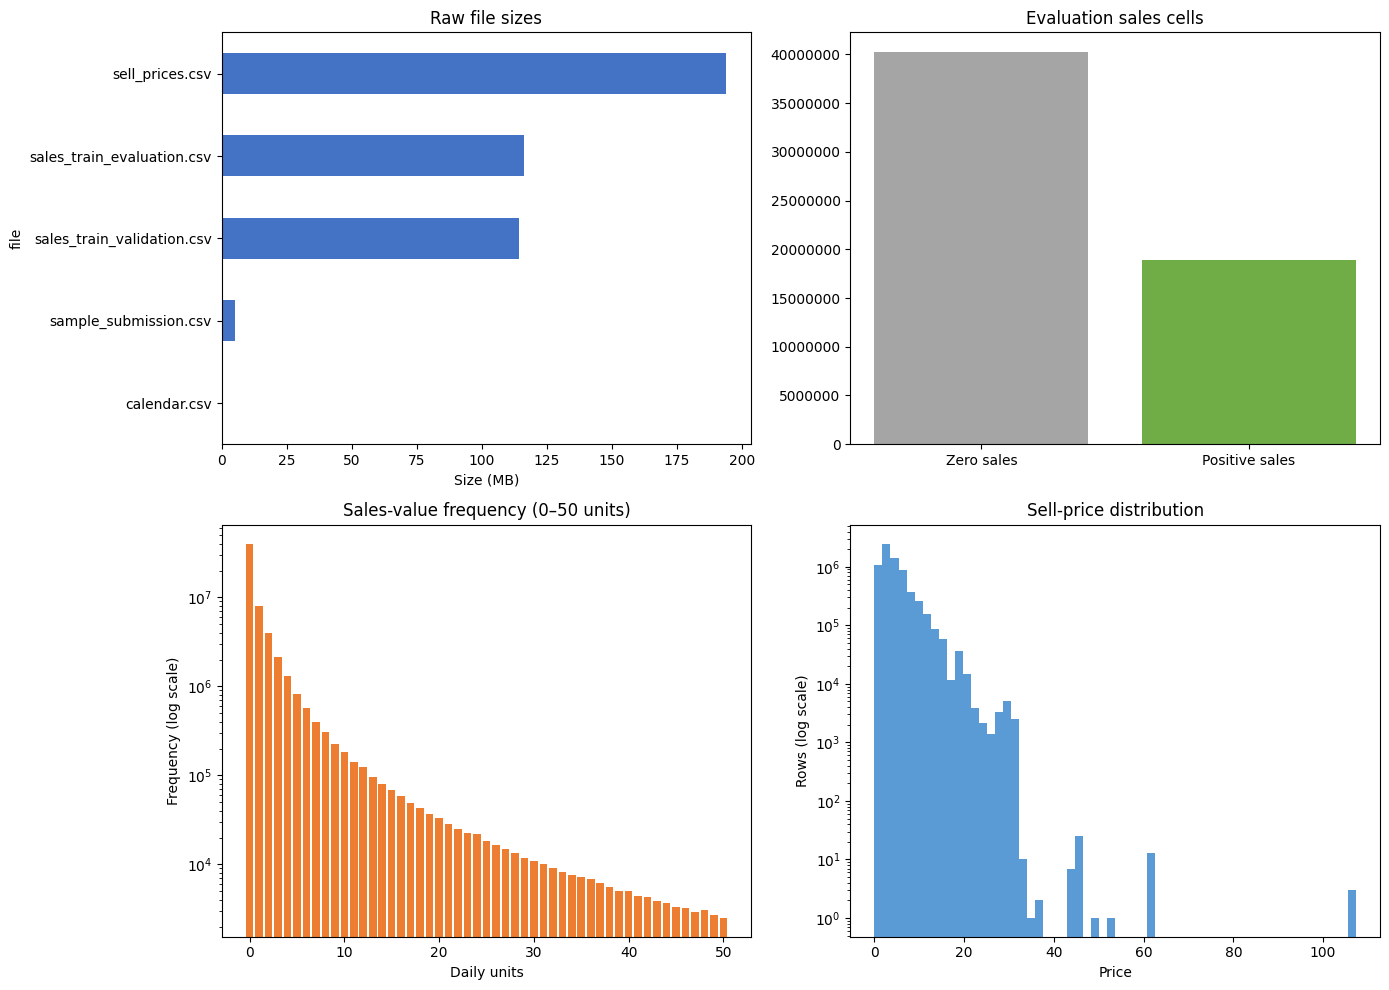

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

inventory.sort_values("size_mb").plot.barh(x="file", y="size_mb", legend=False, ax=axes[0, 0], color="#4472C4")
axes[0, 0].set_title("Raw file sizes")
axes[0, 0].set_xlabel("Size (MB)")

zero_counts = [evaluation_result["zero_sales"], evaluation_result["total_sales_cells"] - evaluation_result["zero_sales"]]
axes[0, 1].bar(["Zero sales", "Positive sales"], zero_counts, color=["#A5A5A5", "#70AD47"])
axes[0, 1].set_title("Evaluation sales cells")
axes[0, 1].ticklabel_format(style="plain", axis="y")

sales_limit = min(50, len(evaluation_histogram) - 1)
axes[1, 0].bar(np.arange(sales_limit + 1), evaluation_histogram[:sales_limit + 1], color="#ED7D31")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Sales-value frequency (0–50 units)")
axes[1, 0].set_xlabel("Daily units")
axes[1, 0].set_ylabel("Frequency (log scale)")

axes[1, 1].hist(price_values, bins=60, color="#5B9BD5")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Sell-price distribution")
axes[1, 1].set_xlabel("Price")
axes[1, 1].set_ylabel("Rows (log scale)")

plt.tight_layout()
plt.show()

## 9. Audit summary and saved reports

`PASS` means that the audited rule found no technical violation. Optional calendar events, zero sales, and values above the 99.9th percentile are documented characteristics rather than automatic errors.

In [9]:
audit_checks = [
    ("calendar", "invalid dates", calendar_result["invalid_dates"]),
    ("calendar", "missing required values", calendar_result["missing_required"]),
    ("calendar", "duplicate date/day keys", calendar_result["duplicate_dates"] + calendar_result["duplicate_day_ids"]),
    ("sales evaluation", "missing or non-numeric sales", evaluation_result["missing_sales"] + evaluation_result["non_numeric_sales"]),
    ("sales evaluation", "negative or fractional sales", evaluation_result["negative_sales"] + evaluation_result["fractional_sales"]),
    ("sales evaluation", "duplicate series keys", evaluation_result["duplicate_series_keys"]),
    ("sales evaluation", "hierarchy conflicts", evaluation_result["item_hierarchy_conflicts"] + evaluation_result["store_state_conflicts"]),
    ("sales validation", "missing or non-numeric sales", validation_result["missing_sales"] + validation_result["non_numeric_sales"]),
    ("sales validation", "negative or fractional sales", validation_result["negative_sales"] + validation_result["fractional_sales"]),
    ("sales validation", "duplicate series keys", validation_result["duplicate_series_keys"]),
    ("sales validation", "hierarchy conflicts", validation_result["item_hierarchy_conflicts"] + validation_result["store_state_conflicts"]),
    ("prices", "missing/invalid/non-positive prices", price_result["missing_prices"] + price_result["non_numeric_prices"] + price_result["non_positive_prices"]),
    ("prices", "invalid or missing business keys", price_result["missing_keys"] + price_result["invalid_weeks"]),
    ("prices", "duplicate business keys", price_result["duplicate_business_keys"]),
    ("submission", "invalid IDs or forecast values", submission_result["missing_ids"] + submission_result["duplicate_ids"] + submission_result["missing_forecasts"] + submission_result["non_numeric_forecasts"] + submission_result["negative_forecasts"]),
    ("cross-file", "key/history mismatches", sum(cross_file_result.values())),
]

audit_summary = pd.DataFrame(audit_checks, columns=["area", "check", "issue_count"])
audit_summary["status"] = np.where(audit_summary["issue_count"].eq(0), "PASS", "REVIEW")
display(audit_summary)

findings = {
    "calendar": calendar_result,
    "calendar_optional_missing": optional_missing.astype(int).to_dict(),
    "sales_evaluation": {key: value for key, value in evaluation_result.items() if key != "unique_counts"},
    "sales_validation": {key: value for key, value in validation_result.items() if key != "unique_counts"},
    "prices": price_result,
    "submission": submission_result,
    "cross_file": cross_file_result,
}

inventory.to_csv(REPORT_DIR / "data_file_inventory.csv", index=False)
audit_summary.to_csv(REPORT_DIR / "data_audit_summary.csv", index=False)
with (REPORT_DIR / "data_audit_findings.json").open("w", encoding="utf-8") as file:
    json.dump(findings, file, indent=2, ensure_ascii=False, default=lambda value: value.item() if hasattr(value, "item") else str(value))

technical_issue_count = int(audit_summary["issue_count"].sum())
print(f"Technical issue count: {technical_issue_count:,}")
print(f"Evaluation zero-sales share: {evaluation_result['zero_sales_pct']:.2f}%")
print(f"Sales values above p99.9 ({evaluation_result['sales_p99_9']} units): {evaluation_result['values_above_p99_9']:,}")
print(f"Prices above p99.9 ({price_result['price_p99_9']:.2f}): {price_result['values_above_p99_9']:,}")
print("Reports saved in:", REPORT_DIR)

,area,check,issue_count,status
0,calendar,invalid dates,0,PASS
1,calendar,missing required values,0,PASS
2,calendar,duplicate date/day keys,0,PASS
3,sales evaluation,missing or non-numeric sales,0,PASS
4,sales evaluation,negative or fractional sales,0,PASS
5,sales evaluation,duplicate series keys,0,PASS
6,sales evaluation,hierarchy conflicts,0,PASS
7,sales validation,missing or non-numeric sales,0,PASS
8,sales validation,negative or fractional sales,0,PASS
9,sales validation,duplicate series keys,0,PASS


Technical issue count: 0
Evaluation zero-sales share: 68.00%
Sales values above p99.9 (47 units): 57,465
Prices above p99.9 (28.96): 6,015
Reports saved in: F:\7) AI-ML_Fundamental_Project\Git_Desktop\retail-demand-forecasting\reports


## 10. How to interpret the result

- Technical problems found by the checks must be handled by the cleaning notebook.
- Empty event fields are expected on ordinary dates and should not be filled with invented events.
- Zero sales are valid observations and should not be removed.
- Values above the 99.9th percentile must be compared with nearby dates, prices, holidays, and product history before any treatment.
- `sales_train_validation.csv` is an earlier prefix of `sales_train_evaluation.csv`; using both as independent training records would duplicate history and cause incorrect evaluation.
- The next step is to review these real findings and approve a leakage-safe cleaning and split plan.